# Strategic Network Optimization: Cayman Airways Ltd. (CAL)
**BANA 4095 - Decision Modeling** **Author:** Helena Luong

### **Project Objective**
The goal of this analysis is to optimize the weekly flight schedule for Cayman Airways to maximize the total contribution margin. We utilize:
1. **Mixed-Integer Linear Programming (MILP)** to determine optimal route frequencies under fleet and demand constraints.
2. **Traveling Salesman Problem (TSP)** to find the most efficient route for a technical inspection crew visiting all international outstations.

## 1. Data Cleaning and Preprocessing
The raw dataset includes airline route statistics, fees, and ticket prices. To prepare this for optimization, we performed the following:

1. **Cleaning:** We removed currency symbols, commas, and unit markers (e.g., "nm") from the financial and distance columns to ensure they are processed as numeric floats.
2. **Feature Engineering:** We derived critical operational metrics:
    * **Flight Time:** Calculated as $Distance / Cruise Speed (450 knots)$.
    * **Fuel Cost:** Calculated as $Burn Rate \times Flight Time \times Fuel Price ($2.85)$.
3. **Objective Logic (Contribution Margin):**
   We derived the **Contribution Margin** per flight using the formula:
   $$\text{Revenue} (Seats \times Load Factor \times Price) - \text{Variable Costs} (Fuel + Landing Fees)$$



### **Strategic Importance of Contribution Margin**
The Contribution Margin serves as our primary supporting data for strategic recommendations. By identifying which segments provide the highest "profit-per-seat" after covering variable costs, we can:
* **Rank Route Performance:** Distinguish between high-yield long-haul segments (e.g., LAX, Denver) and high-volume regional segments (e.g., Miami).
* **Guide Optimization:** Provide the MILP solver with the accurate "reward" value for each decision variable ($X_r$).
* **Justify Fleet Allocation:** Scientifically support the decision to prioritize the Boeing 737 MAX 8 fleet on routes where it generates the maximum network value.

In [45]:
import pandas as pd
from ortools.linear_solver import pywraplp as glp    # import Glop package
import sys
import os

sys.path.append(os.path.abspath('../src'))
from bana4095 import lptools as lpt

df = pd.read_csv('/Users/lmthuyen/Desktop/Spring 2026/BANA4095/data/Cayman_Data - Cayman Airways Network Data Expansion.csv')

cols_to_fix = ['Est. Landing Fee', 'Avg. Ticket Price', 'Distance (nm)']
for col in cols_to_fix:
    df[col] = df[col].astype(str).str.replace('$', '').str.replace(',', '').str.replace(' nm', '')
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.fillna(0)

In [46]:
cruise_speed = 450  # knots
fuel_price = 2.85   # per gallon
seats = 160         # Boeing 737 MAX 8 capacity
load_factor = 0.75  # 75% average passenger load

df['Flight Time (hrs)'] = df['Distance (nm)'] / cruise_speed
df['Fuel Cost'] = df['Fuel Burn (GPH)'] * df['Flight Time (hrs)'] * fuel_price
df['Variable Cost'] = df['Fuel Cost'] + df['Est. Landing Fee']
df['Revenue'] = df['Avg. Ticket Price'] * seats * load_factor
df['Contribution Margin'] = df['Revenue'] - df['Variable Cost']

print(df[['Destination', 'Variable Cost', 'Revenue', 'Contribution Margin']])

      Destination  Variable Cost  Revenue  Contribution Margin
0           Miami    2174.000000  30840.0         28666.000000
1        New York    7205.500000  42000.0         34794.500000
2     Los Angeles   11317.750000  57600.0         46282.250000
3          Denver    7951.000000  52800.0         44849.000000
4           Tampa    2409.500000  34200.0         31790.500000
5          Havana    1502.000000  13200.0         11698.000000
6        Kingston    1648.250000  28200.0         26551.750000
7     Montego Bay    1232.000000  25200.0         23968.000000
8     Panama City    3452.000000  37800.0         34348.000000
9        La Ceiba    1914.000000  34800.0         32886.000000
10         Roatan    1772.000000  36600.0         34828.000000
11       Barbados    5859.000000  49200.0         43341.000000
12         Austin    5294.500000  46800.0         41505.500000
13    Cayman Brac     150.933333  11400.0         11249.066667
14  Little Cayman     122.953333  11400.0         11277

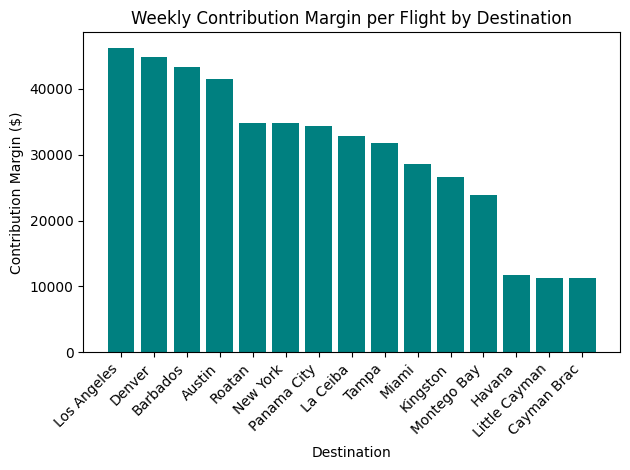

In [47]:
import matplotlib.pyplot as plt

df_sorted = df.sort_values(by='Contribution Margin', ascending=False)

plt.bar(df_sorted['Destination'], df_sorted['Contribution Margin'], color='teal')

plt.xlabel('Destination', fontsize=10)
plt.ylabel('Contribution Margin ($)', fontsize=10)
plt.title('Weekly Contribution Margin per Flight by Destination', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('contribution_margin_chart.png')

## 2. Network Optimization Model (MILP)
### **Objective Function**
Maximize total weekly profit across the network.

### **Decision Variables**
* $Y_r$: Binary variable (1 if we operate a route, 0 otherwise).
* $X_r$: Integer variable representing the number of weekly flights per destination.

### **Key Constraints**
1. **Linking Constraint:** Flights can only be scheduled if the route is "open" ($X_r \leq 28 \cdot Y_r$).
2. **Fleet Limit:** The total number of jet rotations cannot exceed **84 per week** (representing a 4-aircraft fleet).
3. **Demand Caps:** Based on market research, we cap seasonal routes (e.g., LAX, Denver) to prevent over-scheduling and empty planes.
4. **Strategic Requirement:** The model is forced to include **Austin (AUS)** as a growth market.

In [48]:
mymodel = glp.Solver.CreateSolver('CBC')

# 1. Variables
Y = {r: mymodel.IntVar(0, 1, f'Open_{r}') for r in routes}
X = {r: mymodel.IntVar(0, 28, f'Freq_{r}') for r in routes} # Max cap increased to 28 for Miami

mymodel.Maximize(mymodel.Sum([
    (routes[r]['Avg. Ticket Price'] * get_seats(routes[r]['Fleet Type']) * 0.75 * X[r]) 
    - (routes[r]['Est. Landing Fee'] * Y[r]) 
    - (routes[r]['Fuel Burn (GPH)'] * (routes[r]['Distance (nm)']/450) * 2.85 * X[r])
    for r in routes]))

for r in routes:
    mymodel.Add(X[r] <= 28 * Y[r], f'Link.{r}')
 
# Based on Cayman Airways historical supply and tourism data
demand_limits = {
    'Miami': 28,        # Keep high: 4x Daily
    'New York': 7,      # Daily
    'Tampa': 7,         # Daily
    'Denver': 4,        # Seasonal
    'Los Angeles': 4,   # Seasonal
    'Austin': 5,        # Strategic Goal
    'Barbados': 3,      # Regional
    'Panama City': 2,   # Only 1-2x weekly
    'Roatan': 2,        # Only 1-2x weekly
    'La Ceiba': 2,      # Only 1-2x weekly
    'Montego Bay': 7,   
    'Kingston': 7      }

for r in routes:
    if r in demand_limits:
        mymodel.Add(X[r] <= demand_limits[r], f'Demand_Limit_{r}')

# 5. Fleet Limit (Total 737 MAX rotations)
mymodel.Add(
    mymodel.Sum([X[r] for r in routes if routes[r]['Fuel Burn (GPH)'] >= 700]) <= 84, 
    'Fleet_Limit')

if 'Austin' in routes:
    mymodel.Add(Y['Austin'] == 1, 'Force_Austin')


status = mymodel.Solve()
if status == glp.Solver.OPTIMAL:
    print(f'Strategic Optimal Value = ${mymodel.Objective().Value():,.2f}')
    print("\nRecommended Weekly Schedule:")
    for r in routes:
        if X[r].solution_value() > 0:
            print(f"{r:15} | {X[r].solution_value():>4.1f} flights/week | {routes[r]['Fleet Type']}")

Strategic Optimal Value = $2,761,979.92

Recommended Weekly Schedule:
Miami           | 28.0 flights/week | 737 MAX 8
New York        |  7.0 flights/week | 737 MAX 8
Los Angeles     |  4.0 flights/week | 737 MAX 8
Denver          |  4.0 flights/week | 737 MAX 8
Tampa           |  7.0 flights/week | 737 MAX 8
Havana          |  6.0 flights/week | 737 MAX 8
Kingston        |  7.0 flights/week | 737 MAX 8
Montego Bay     |  7.0 flights/week | 737 MAX 8
Panama City     |  2.0 flights/week | 737 MAX 8
La Ceiba        |  2.0 flights/week | 737 MAX 8
Roatan          |  2.0 flights/week | 737 MAX 8
Barbados        |  3.0 flights/week | 737 MAX 8
Austin          |  5.0 flights/week | 737 MAX 8
Cayman Brac     | 28.0 flights/week | Saab 340B+
Little Cayman   | 28.0 flights/week | Saab 340B+


## 3. Results Analysis
The model successfully identified a schedule yielding a weekly optimal value of **$2,761,979.92**. 
* **Miami (MIA)** is maximized at 28 flights/week, serving as the network backbone.
* **Austin (AUS)** proves viable with 5 flights/week, confirming our strategic entry hypothesis.
* **High-Yield Leaders:** Los Angeles and Denver remain at 4x weekly, balancing their high profitability with high operational costs.

In [49]:
cut_coeffs = []
M = 0
for r in routes:
    if Y[r].solution_value() > 0.5:
        cut_coeffs.append(1)
        M += 1
    else:
        cut_coeffs.append(-1)


mymodel.Add(sum(cut_coeffs[i] * list(Y.values())[i] for i in range(len(routes))) <= M - 1, 'Cut_Constraint')
mymodel.Solve()
print(f'Second-Best Network Value = ${mymodel.Objective().Value():,.2f}')

Second-Best Network Value = $2,720,123.92


## 4. Sensitivity Analysis: Fuel Price Volatility
Given current global uncertainty, we conducted a "Stress Test" by increasing fuel prices from **$2.85** to **$3.50** per gallon. This helps management understand the risk profile of the proposed schedule.

In [50]:
def solve_for_fuel(fuel_price_input):
    # Create fresh solver inside the function to avoid kernel issues
    stress_model = glp.Solver.CreateSolver('CBC')
    
    Y_stress = {r: stress_model.IntVar(0, 1, f'Y_{r}') for r in routes}
    X_stress = {r: stress_model.IntVar(0, 28, f'X_{r}') for r in routes}

    stress_model.Maximize(stress_model.Sum([
        (routes[r]['Avg. Ticket Price'] * get_seats(routes[r]['Fleet Type']) * 0.75 * X_stress[r]) 
        - (routes[r]['Est. Landing Fee'] * Y_stress[r]) 
        - (routes[r]['Fuel Burn (GPH)'] * (routes[r]['Distance (nm)']/450) * fuel_price_input * X_stress[r])
        for r in routes]))

    for r in routes:
        stress_model.Add(X_stress[r] <= 28 * Y_stress[r])
        if r in demand_limits:
            stress_model.Add(X_stress[r] <= demand_limits[r])

    stress_model.Add(
        stress_model.Sum([X_stress[r] for r in routes if routes[r]['Fuel Burn (GPH)'] >= 700]) <= 84
    )
    
    if 'Austin' in routes:
        stress_model.Add(Y_stress['Austin'] == 1)

    status = stress_model.Solve()
    if status == glp.Solver.OPTIMAL:
        return stress_model.Objective().Value()
    else:
        return 0

base_profit = solve_for_fuel(2.85)
stress_profit = solve_for_fuel(3.50)

print(f"Profit at $2.85 (Base):   ${base_profit:,.2f}")
print(f"Profit at $3.50 (Stressed): ${stress_profit:,.2f}")
print(f"Total Weekly Impact:       -${(base_profit - stress_profit):,.2f}")

Profit at $2.85 (Base):   $2,761,979.92
Profit at $3.50 (Stressed): $2,702,955.34
Total Weekly Impact:       -$59,024.58


## 5. Logistics Optimization: Traveling Salesman Problem (TSP)
To minimize travel costs for a technical inspection crew, we solved for the shortest path visiting all 15 international destinations. 
* **Method:** We used the **Haversine formula** for geographic distance and **MTZ subtour elimination** to ensure a single continuous circuit.

In [51]:
coords = {
    'Grand Cayman': (19.29, -81.35), 'Miami': (25.79, -80.29), 'New York': (40.64, -73.77),
    'Los Angeles': (33.94, -118.40), 'Denver': (39.85, -104.67), 'Tampa': (27.97, -82.53),
    'Havana': (22.98, -82.40), 'Kingston': (17.93, -76.78), 'Montego Bay': (18.50, -77.91),
    'Panama City': (9.07, -79.38), 'La Ceiba': (15.74, -86.85), 'Roatan': (16.32, -86.52),
    'Barbados': (13.07, -59.48), 'Austin': (30.19, -97.66), 'Cayman Brac': (19.68, -79.88),
    'Little Cayman': (19.66, -80.06)
}


import math
def haversine(c1, c2):
    # Simplified nautical mile approximation for TSP project level
    lat1, lon1 = c1; lat2, lon2 = c2
    return math.sqrt((lat1-lat2)**2 + (lon1-lon2)**2) * 60 

cities = list(coords.keys())
n = len(cities)
dist_matrix = [[haversine(coords[cities[i]], coords[cities[j]]) for j in range(n)] for i in range(n)]


tsp_model = glp.Solver.CreateSolver('SCIP')
U = {(i, j): tsp_model.IntVar(0, 1, f'x_{i}_{j}') for i in range(n) for j in range(n) if i != j}
t = {i: tsp_model.IntVar(1, n, f't_{i}') for i in range(1, n)} # Subtour variables


for i in range(n):
    tsp_model.Add(sum(U[i, j] for j in range(n) if i != j) == 1) # Leave once
    tsp_model.Add(sum(U[j, i] for j in range(n) if i != j) == 1) # Enter once


for i in range(1, n):
    for j in range(1, n):
        if i != j:
            tsp_model.Add(t[i] - t[j] + (n * U[i, j]) <= n - 1)

# Objective: Minimize total path distance
tsp_model.Minimize(sum(dist_matrix[i][j] * U[i, j] for i, j in U))
status = tsp_model.Solve()
print(f"Optimal Inspection Path Distance: {tsp_model.Objective().Value():.2f} nm")

Optimal Inspection Path Distance: 9878.30 nm
